In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

DATASET_NAME = "data03"
DATASET_LABEL = DATASET_NAME.replace("_", " ").title()
DATASET_LOW_LABEL = f"{DATASET_LABEL} low"
FIGURE_DIR_NAME = "S2"


def resolve_figure_dir():
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]
    candidates = []
    for root in search_roots:
        if root.name == FIGURE_DIR_NAME:
            candidates.append(root)
        candidates.extend(
            [
                root / "Benchmark-RNA-velocity" / "Figure_reproduction" / FIGURE_DIR_NAME,
                root / "Figure_reproduction" / FIGURE_DIR_NAME,
            ]
        )

    for candidate in candidates:
        if (candidate / DATASET_NAME).exists():
            return candidate

    raise FileNotFoundError(f"Could not locate Figure_reproduction/{FIGURE_DIR_NAME}/{DATASET_NAME}")


FIGURE_DIR = resolve_figure_dir()


def resolve_s2_data_dir(*required_files):
    candidates = [FIGURE_DIR / DATASET_NAME, FIGURE_DIR]

    for candidate in candidates:
        if all((candidate / file_name).exists() for file_name in required_files):
            return candidate

    raise FileNotFoundError(
        f"Could not find required files {required_files} in any of: {candidates}"
    )

base_dir = resolve_s2_data_dir("cbdir_low_df.csv")

METHOD_ALIASES = {
    "scvelo_dy": "scvelo_dyn",
    "scvelo_st": "scvelo_stc",
    "dynamo": "dynamo_m1",
    "velovae": "velovae_std",
    "velovae_full": "velovae_fullvb",
    "deepvelo_gcn": "deepvelo",
    "pyro_model1": "pyrovelocity_m1",
    "pyro_model2": "pyrovelocity_m2",
    "kappa": "kvelo",
    "latentvelo": "latentvelo_std",
    "tivelo": "tivelo_std",
    "graphvelo": "graphvelo_std",
}


def prepare_metric_means(file_name, value_col, method_aliases=None):
    df = pd.read_csv(base_dir / file_name)

    if method_aliases is not None:
        df["Method"] = df["Method"].replace(method_aliases)

    # 除了 Method 之外，其余列都视为不同 fold，先对每个方法取平均。
    fold_cols = [col for col in df.columns if col != "Method"]
    mean_df = df.assign(**{value_col: df[fold_cols].mean(axis=1)})[["Method", value_col]]

    # 别名映射后如果有重复方法名，这里再聚合一次，保证后续 merge 干净。
    return mean_df.groupby("Method", as_index=False)[value_col].mean()


def analyze_metric(
    metric_name,
    x_file,
    y_file,
    x_key,
    y_key,
    x_label,
    y_label,
    method_aliases=None,
    value_ax=None,
    rank_ax=None,
):
    x_col = f"{metric_name}_{x_key}_mean"
    y_col = f"{metric_name}_{y_key}_mean"

    x_mean = prepare_metric_means(x_file, x_col, method_aliases=method_aliases)
    y_mean = prepare_metric_means(y_file, y_col, method_aliases=method_aliases)

    x_methods = set(x_mean["Method"])
    y_methods = set(y_mean["Method"])
    x_only_methods = sorted(x_methods - y_methods)
    y_only_methods = sorted(y_methods - x_methods)

    merged = (
        x_mean.merge(y_mean, on="Method", how="inner")
        .sort_values("Method")
        .reset_index(drop=True)
    )

    x_rank_col = f"{metric_name}_{x_key}_rank"
    y_rank_col = f"{metric_name}_{y_key}_rank"
    merged[x_rank_col] = merged[x_col].rank(ascending=False, method="average")
    merged[y_rank_col] = merged[y_col].rank(ascending=False, method="average")

    pearson_corr = merged[x_col].corr(merged[y_col], method="pearson")
    spearman_corr = merged[x_col].corr(merged[y_col], method="spearman")
    rank_spearman_corr = merged[x_rank_col].corr(merged[y_rank_col], method="spearman")

    print(f"===== {metric_name}: {x_label} vs {y_label} =====")
    print(f"共有方法数: {len(merged)}")
    if x_only_methods:
        print(f"仅在 {x_label} 中出现的方法: {x_only_methods}")
    if y_only_methods:
        print(f"仅在 {y_label} 中出现的方法: {y_only_methods}")
    print(f"Pearson correlation: {pearson_corr:.4f}")
    print(f"Spearman correlation: {spearman_corr:.4f}")
    print(f"Rank Spearman correlation: {rank_spearman_corr:.4f}")
    display(merged.sort_values(x_rank_col).reset_index(drop=True))

    if value_ax is not None:
        value_ax.scatter(merged[x_col], merged[y_col], s=60, alpha=0.8)
        for _, row in merged.iterrows():
            value_ax.annotate(
                row["Method"],
                (row[x_col], row[y_col]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )
        value_ax.set_title(f"{metric_name}: {x_label} vs {y_label} mean")
        value_ax.set_xlabel(f"{x_label} {metric_name} mean")
        value_ax.set_ylabel(f"{y_label} {metric_name} mean")
        value_ax.grid(alpha=0.3)

    if rank_ax is not None:
        rank_ax.scatter(merged[x_rank_col], merged[y_rank_col], s=60, alpha=0.8, color="tab:orange")
        for _, row in merged.iterrows():
            rank_ax.annotate(
                row["Method"],
                (row[x_rank_col], row[y_rank_col]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )
        rank_ax.set_title(f"{metric_name}: {x_label} vs {y_label} rank")
        rank_ax.set_xlabel(f"{x_label} {metric_name} rank")
        rank_ax.set_ylabel(f"{y_label} {metric_name} rank")
        rank_ax.grid(alpha=0.3)

    return merged, pearson_corr, spearman_corr, rank_spearman_corr

# Legacy plotting calls were removed. The standalone rank-scatter plots are generated in the cells below.


In [2]:
import numpy as np
from scipy.stats import spearmanr

high_dir = resolve_s2_data_dir("cbdir_low_df.csv")

method_colors = {
    'velocyto': "#6587AB",
    'scvelo_dyn': "#76B7B2",
    'scvelo_stc': "#92CB8A",
    'veloae': "#F6A24F",
    'dynamo_m1': "#DC6F71",
    'pyrovelocity_m1': "#006e54",
    'pyrovelocity_m2': "#a7e6d7",
    'unitvelo_uni': "#aa4c8f",
    'unitvelo_ind': "#E9B6DA",
    'velovae_std': "#C6A11B",
    'velovae_fullvb': "#FBEBB2",
    'kvelo': "#FAAEA0",
    'celldancer': "#7ABBEF",
    'velovi': "#A4AB47",
    'latentvelo_std': "#C4D6A0",
    'sctour_mse': "#4d5aaf",
    'sctour_nb': "#8491c3",
    'sctour_zinb': "#bbc8e6",
    'deepvelo': "#D2660D",
    'sdevelo': "#22808B",
    'svelvetvae': "#F6D55C",
    'cell2fate': "#AD2513",
    'tivelo_std': "#333631",
    'tivelo_simple': "#AFB39F",
    'graphvelo_std': "#8D6262"
}


def prepare_metric_rank_df(file_name, value_col, method_aliases=None, data_dir=None):
    data_dir = high_dir if data_dir is None else Path(data_dir)
    df = pd.read_csv(data_dir / file_name)

    if method_aliases is not None:
        df["Method"] = df["Method"].replace(method_aliases)

    fold_cols = [col for col in df.columns if col != "Method"]
    mean_df = df.assign(**{value_col: df[fold_cols].mean(axis=1)})[["Method", value_col]]
    mean_df = mean_df.groupby("Method", as_index=False)[value_col].mean()
    return mean_df


def plot_rank_scatter(
    metric_name,
    x_file,
    y_file,
    x_label,
    y_label,
    output_name,
    method_aliases=None,
):
    x_value_col = f"{metric_name}_{x_label.lower().replace('-', '_').replace(' ', '_')}_mean"
    y_value_col = f"{metric_name}_{y_label.lower().replace('-', '_').replace(' ', '_')}_mean"

    x_df = prepare_metric_rank_df(x_file, x_value_col, method_aliases=method_aliases)
    y_df = prepare_metric_rank_df(y_file, y_value_col, method_aliases=method_aliases)

    merged = x_df.merge(y_df, on="Method", how="inner")
    x_rank_col = f"{x_value_col}_rank"
    y_rank_col = f"{y_value_col}_rank"
    merged[x_rank_col] = merged[x_value_col].rank(ascending=False, method="min").astype(int)
    merged[y_rank_col] = merged[y_value_col].rank(ascending=False, method="min").astype(int)

    rho, p_value = spearmanr(merged[x_rank_col], merged[y_rank_col])

    max_rank = int(max(merged[x_rank_col].max(), merged[y_rank_col].max()))
    if max_rank <= 5:
        ticks = np.arange(1, max_rank + 1)
    else:
        ticks = np.array(sorted(set([1] + list(range(5, max_rank + 1, 5)) + [max_rank])))

    point_colors = merged["Method"].map(lambda method: method_colors.get(method, "#999999"))

    fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=150)
    ax.scatter(merged[x_rank_col], merged[y_rank_col], s=42, c=point_colors, alpha=0.95, edgecolor="none")
    ax.plot([1, max_rank], [1, max_rank], linestyle="--", color="red", linewidth=1)

    ax.set_xlim(0.5, max_rank + 0.5)
    ax.set_ylim(0.5, max_rank + 0.5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    ax.grid(False)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["top"].set_linewidth(1)
    ax.spines["right"].set_linewidth(1)
    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=4,
        width=1,
        colors="black",
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelsize=12,
    )

    plt.tight_layout()
    plt.savefig(high_dir / output_name, bbox_inches="tight", dpi=150)
    plt.show()

    return merged, rho, p_value


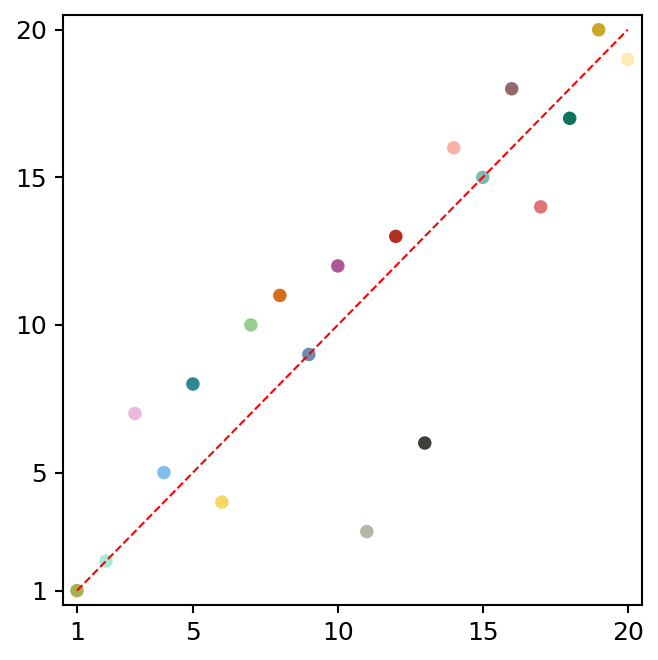

CBDir high vs low Spearman rho = 0.860, p = 1.157e-06


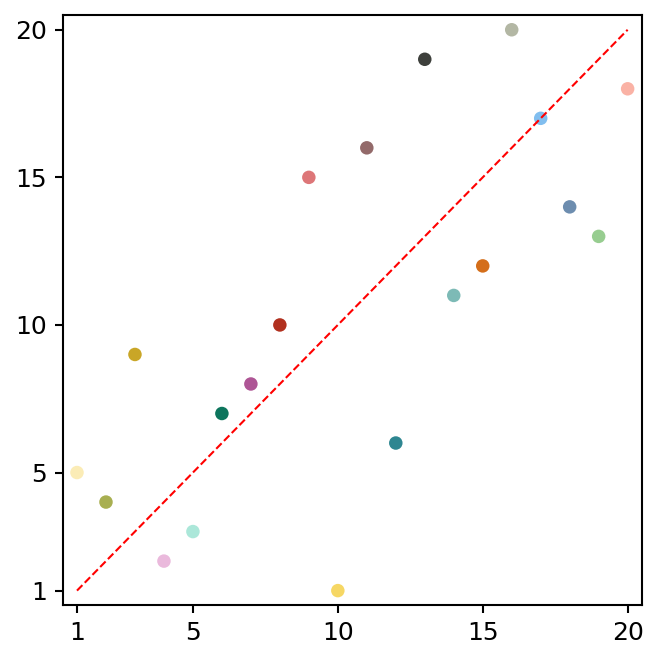

ICVCoh high vs low Spearman rho = 0.719, p = 3.559e-04


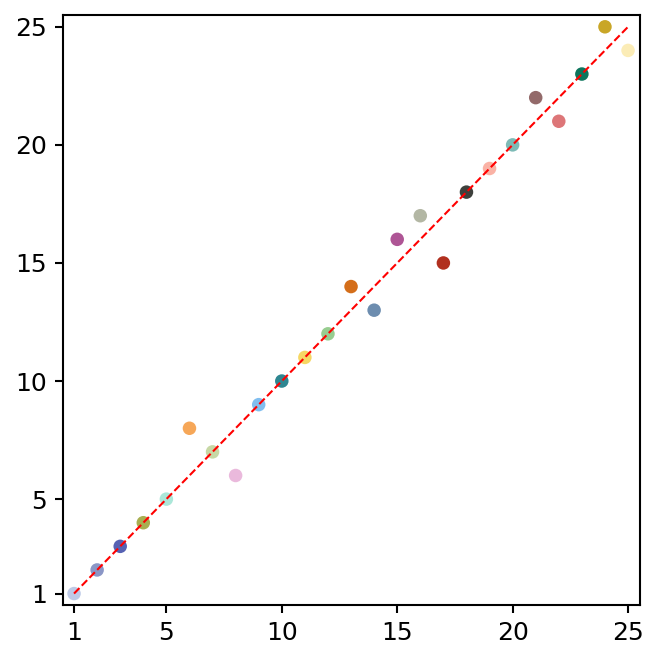

CBDir PCA vs low Spearman rho = 0.992, p = 2.247e-22


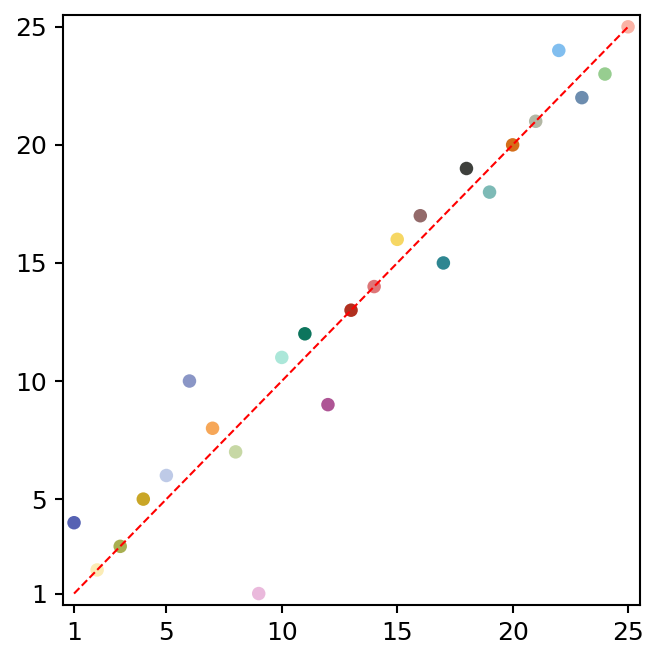

ICVCoh PCA vs low Spearman rho = 0.955, p = 1.369e-13


In [3]:
cbdir_high_low_result = plot_rank_scatter(
    metric_name="cbdir",
    x_file="cbdir_low_df.csv",
    y_file="cbdir_high_df.csv",
    x_label="Low-dimensional",
    y_label="High-dimensional",
    output_name="cbdir_high_vs_low_rank_scatter.png",
)
print(f"CBDir high vs low Spearman rho = {cbdir_high_low_result[1]:.3f}, p = {cbdir_high_low_result[2]:.3e}")

icvcoh_high_low_result = plot_rank_scatter(
    metric_name="icvcoh",
    x_file="icvcoh_low_df.csv",
    y_file="icvcoh_high_df.csv",
    x_label="Low-dimensional",
    y_label="High-dimensional",
    output_name="icvcoh_high_vs_low_rank_scatter.png",
)
print(f"ICVCoh high vs low Spearman rho = {icvcoh_high_low_result[1]:.3f}, p = {icvcoh_high_low_result[2]:.3e}")

cbdir_pca_low_result = plot_rank_scatter(
    metric_name="cbdir",
    x_file="cbdir_low_df.csv",
    y_file="cbdir_df_pca.csv",
    x_label="Low-dimensional",
    y_label="PCA",
    output_name="cbdir_pca_vs_low_rank_scatter.png",
    method_aliases=METHOD_ALIASES,
)
print(f"CBDir PCA vs low Spearman rho = {cbdir_pca_low_result[1]:.3f}, p = {cbdir_pca_low_result[2]:.3e}")

icvcoh_pca_low_result = plot_rank_scatter(
    metric_name="icvcoh",
    x_file="icvcoh_low_df.csv",
    y_file="icvcoh_df_pca.csv",
    x_label="Low-dimensional",
    y_label="PCA",
    output_name="icvcoh_pca_vs_low_rank_scatter.png",
    method_aliases=METHOD_ALIASES,
)
print(f"ICVCoh PCA vs low Spearman rho = {icvcoh_pca_low_result[1]:.3f}, p = {icvcoh_pca_low_result[2]:.3e}")


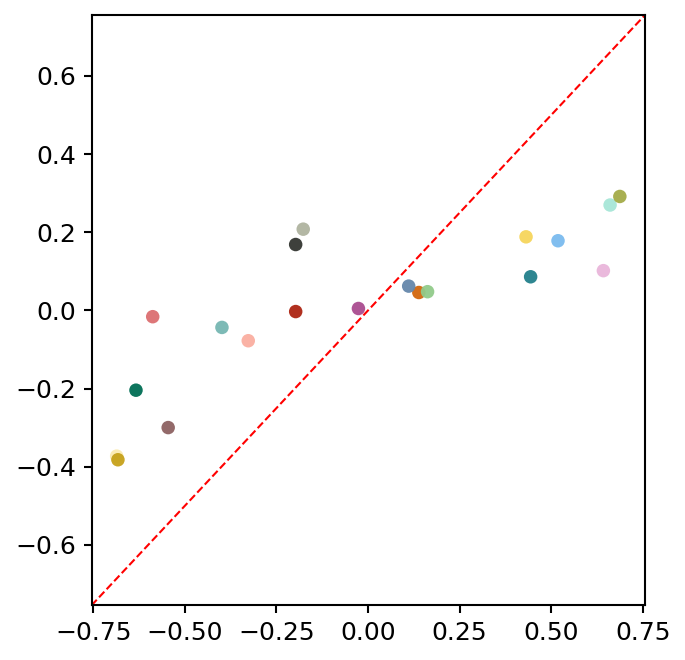

CBDir high vs low raw-value Pearson r = 0.820, p = 9.811e-06; Spearman rho = 0.860, p = 1.157e-06


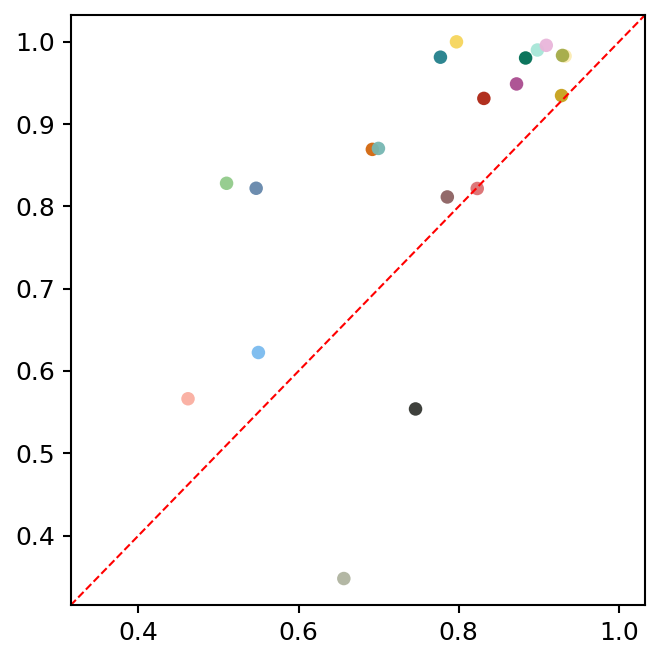

ICVCoh high vs low raw-value Pearson r = 0.648, p = 2.019e-03; Spearman rho = 0.719, p = 3.559e-04


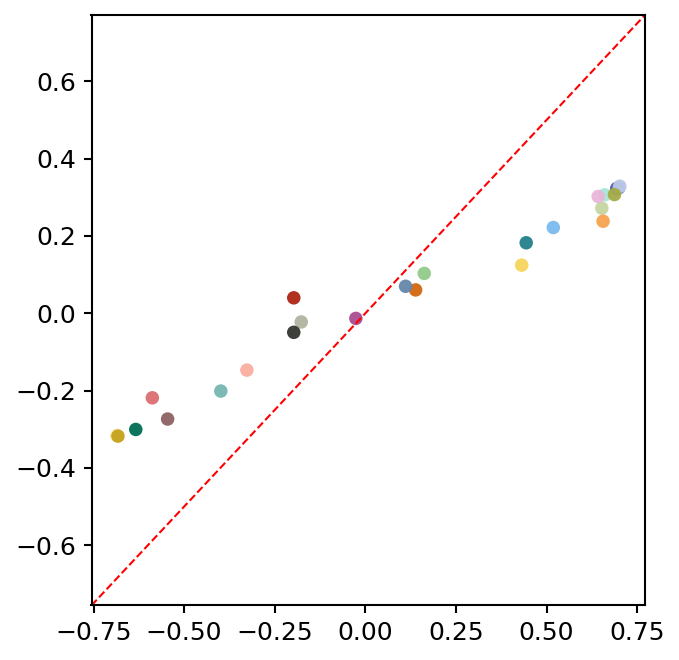

CBDir PCA vs low raw-value Pearson r = 0.986, p = 1.834e-19; Spearman rho = 0.992, p = 2.247e-22


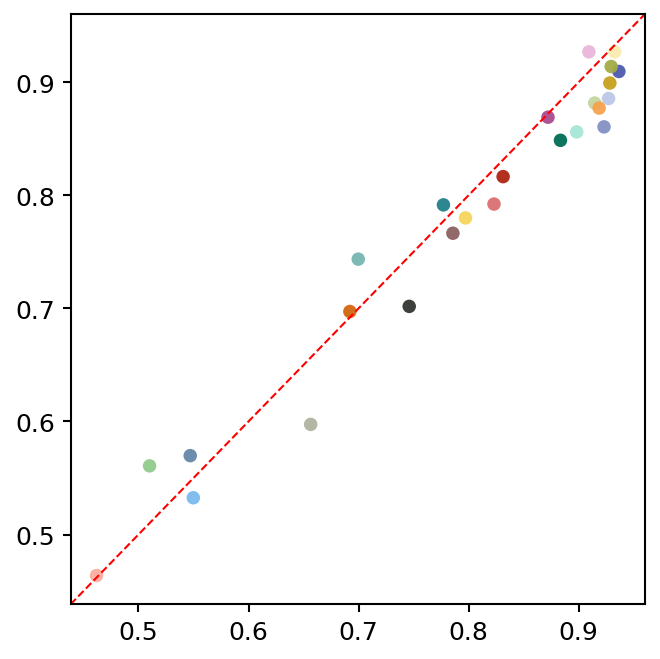

ICVCoh PCA vs low raw-value Pearson r = 0.983, p = 2.651e-18; Spearman rho = 0.955, p = 1.369e-13


In [4]:
from scipy.stats import pearsonr

def plot_value_scatter(
    metric_name,
    x_file,
    y_file,
    x_label,
    y_label,
    output_name,
    method_aliases=None,
):
    x_value_col = f"{metric_name}_{x_label.lower().replace('-', '_').replace(' ', '_')}_mean"
    y_value_col = f"{metric_name}_{y_label.lower().replace('-', '_').replace(' ', '_')}_mean"

    x_df = prepare_metric_rank_df(x_file, x_value_col, method_aliases=method_aliases)
    y_df = prepare_metric_rank_df(y_file, y_value_col, method_aliases=method_aliases)

    merged = x_df.merge(y_df, on="Method", how="inner")
    pearson_r, pearson_p = pearsonr(merged[x_value_col], merged[y_value_col])
    spearman_r, spearman_p = spearmanr(merged[x_value_col], merged[y_value_col])

    point_colors = merged["Method"].map(lambda method: method_colors.get(method, "#999999"))
    value_min = min(merged[x_value_col].min(), merged[y_value_col].min())
    value_max = max(merged[x_value_col].max(), merged[y_value_col].max())
    padding = (value_max - value_min) * 0.05 if value_max > value_min else 0.05
    lower = value_min - padding
    upper = value_max + padding

    fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=150)
    ax.scatter(merged[x_value_col], merged[y_value_col], s=42, c=point_colors, alpha=0.95, edgecolor="none")
    ax.plot([lower, upper], [lower, upper], linestyle="--", color="red", linewidth=1)

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    ax.grid(False)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["top"].set_linewidth(1)
    ax.spines["right"].set_linewidth(1)
    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=4,
        width=1,
        colors="black",
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelsize=12,
    )

    plt.tight_layout()
    plt.savefig(high_dir / output_name, bbox_inches="tight", dpi=150)
    plt.show()

    return merged, pearson_r, pearson_p, spearman_r, spearman_p


cbdir_high_low_value_result = plot_value_scatter(
    metric_name="cbdir",
    x_file="cbdir_low_df.csv",
    y_file="cbdir_high_df.csv",
    x_label="Low-dimensional",
    y_label="High-dimensional",
    output_name="cbdir_high_vs_low_value_scatter.png",
)
print(
    f"CBDir high vs low raw-value Pearson r = {cbdir_high_low_value_result[1]:.3f}, p = {cbdir_high_low_value_result[2]:.3e}; "
    f"Spearman rho = {cbdir_high_low_value_result[3]:.3f}, p = {cbdir_high_low_value_result[4]:.3e}"
)

icvcoh_high_low_value_result = plot_value_scatter(
    metric_name="icvcoh",
    x_file="icvcoh_low_df.csv",
    y_file="icvcoh_high_df.csv",
    x_label="Low-dimensional",
    y_label="High-dimensional",
    output_name="icvcoh_high_vs_low_value_scatter.png",
)
print(
    f"ICVCoh high vs low raw-value Pearson r = {icvcoh_high_low_value_result[1]:.3f}, p = {icvcoh_high_low_value_result[2]:.3e}; "
    f"Spearman rho = {icvcoh_high_low_value_result[3]:.3f}, p = {icvcoh_high_low_value_result[4]:.3e}"
)

cbdir_pca_low_value_result = plot_value_scatter(
    metric_name="cbdir",
    x_file="cbdir_low_df.csv",
    y_file="cbdir_df_pca.csv",
    x_label="Low-dimensional",
    y_label="PCA",
    output_name="cbdir_pca_vs_low_value_scatter.png",
    method_aliases=METHOD_ALIASES,
)
print(
    f"CBDir PCA vs low raw-value Pearson r = {cbdir_pca_low_value_result[1]:.3f}, p = {cbdir_pca_low_value_result[2]:.3e}; "
    f"Spearman rho = {cbdir_pca_low_value_result[3]:.3f}, p = {cbdir_pca_low_value_result[4]:.3e}"
)

icvcoh_pca_low_value_result = plot_value_scatter(
    metric_name="icvcoh",
    x_file="icvcoh_low_df.csv",
    y_file="icvcoh_df_pca.csv",
    x_label="Low-dimensional",
    y_label="PCA",
    output_name="icvcoh_pca_vs_low_value_scatter.png",
    method_aliases=METHOD_ALIASES,
)
print(
    f"ICVCoh PCA vs low raw-value Pearson r = {icvcoh_pca_low_value_result[1]:.3f}, p = {icvcoh_pca_low_value_result[2]:.3e}; "
    f"Spearman rho = {icvcoh_pca_low_value_result[3]:.3f}, p = {icvcoh_pca_low_value_result[4]:.3e}"
)
